# Análise da Rede Social de *Game of Thrones* — Fase Final
### Projeto GRC & IRN | ISCTE-Sintra | Docente: José Barros

**Grupo:** Ilie Iftime (112779) · Inês Cruz (123557) · Sofia Quintino (123554) · Tomás Manarte (122090)

---

**Dataset:** Beveridge (2018) — guiões da série televisiva HBO (T1–T8), [github.com/mathbeveridge/gameofthrones](https://github.com/mathbeveridge/gameofthrones).

**Questão de Investigação (RQ):**
> *Quais as personagens e grupos estruturalmente determinantes na rede social de Game of Thrones, e de que forma a perda progressiva de nós centrais ao longo dos arcos narrativos altera a coesão e a modularidade da rede?*

Este notebook está organizado em cinco etapas. Cada métrica ou algoritmo é precedido da sua **formulação matemática em LaTeX**, conforme exigido pelo guião. As etapas mapeiam os três entregáveis: a Etapa 1 consolida o Entregável 1, as Etapas 2 e 4 o Entregável 2, e as Etapas 3 e 5 o Entregável 3.

---
# Etapa 1 — Setup, Reprodutibilidade e Dados

Fixa-se `SEED = 42` globalmente para garantir reprodutibilidade dos resultados estocásticos (amostragem de grafos de Erdős–Rényi e inicialização dos pesos da GCN). Importam-se as bibliotecas necessárias.

In [4]:

import os, math, heapq, warnings
from collections import deque

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

from networkx.algorithms.community import greedy_modularity_communities, girvan_newman
from networkx.algorithms.community.quality import modularity
from networkx.algorithms.flow import edmonds_karp

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# Configs para plotagem dos gráficos
plt.rcParams.update({'font.family':'serif','axes.spines.top':False,
                     'axes.spines.right':False,'figure.dpi':120})
print('Setup concluído. SEED =', SEED)

Setup concluído. SEED = 42


## 1.1 Definição matemática do Grafo

O sistema é modelado como um **grafo não-orientado e ponderado**:

$$G = (V, E, w), \qquad w: E \rightarrow \mathbb{N}$$

onde $V$ é o conjunto de personagens, $E \subseteq \{\{u,v\} : u,v \in V\}$ o conjunto de interações, e $w(e)$ o número de coocorrências da aresta $e$. A escolha de grafo não-orientado decorre da **simetria** da coocorrência: se $u$ surge em cena com $v$, então $v$ surge com $u$.

### Carregamento e verificações de integridade

Como o mesmo par pode interagir em várias temporadas, agregam-se os pesos:

$$w_{agg}(u,v) = \sum_{s=1}^{8} w_s(u,v)$$

Verifica-se automaticamente: (i) IDs duplicados nos nós; (ii) arestas simétricas/duplicadas; (iii) pesos negativos (inválidos).

In [5]:
# Ilie path
# DATA_DIR = r"C:\Users\iliei\OneDrive\Ambiente de Trabalho\Universidade 3º ano\2º Semestre\Introdução Redes Neuronais\Projeto final\v1 final esboco"



In [6]:
import os

# Resolve automaticamente a pasta de dados (cwd ou diretórios pai)
folders = [os.path.join(os.getcwd(), 'data')]
for i in range(1, 5):
    folders.append(os.path.join(os.path.abspath(os.path.join(os.getcwd(), *(['..'] * i))), 'data'))

BASE_DATA_DIR = next(
    (
        p for p in folders
        if os.path.exists(os.path.join(p, 'nodes', 'got-s1-nodes.csv'))
        and os.path.exists(os.path.join(p, 'edges', 'got-s1-edges.csv'))
    ),
    os.path.join(os.getcwd(), 'data')  # fallback
)
NODES_DIR = os.path.join(BASE_DATA_DIR, 'nodes')
EDGES_DIR = os.path.join(BASE_DATA_DIR, 'edges')

required_files = [
    os.path.join(NODES_DIR, 'got-s1-nodes.csv'),
    os.path.join(EDGES_DIR, 'got-s1-edges.csv'),
]
missing = [p for p in required_files if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(f'CSVs nao encontrados. Em falta: {missing}')

print(f'Dados em: {BASE_DATA_DIR}')
print(f'Nos em: {NODES_DIR}')
print(f'Arestas em: {EDGES_DIR}')

Dados em: c:\Users\tomas\Desktop\projeto IRN\IRN-Projeto-GoT\data
Nos em: c:\Users\tomas\Desktop\projeto IRN\IRN-Projeto-GoT\data\nodes
Arestas em: c:\Users\tomas\Desktop\projeto IRN\IRN-Projeto-GoT\data\edges


In [7]:
all_nodes, all_edges = [], []
for s in range(1, 9):
    node_file = os.path.join(NODES_DIR, f'got-s{s}-nodes.csv')
    edge_file = os.path.join(EDGES_DIR, f'got-s{s}-edges.csv')
    try:
        dn = pd.read_csv(node_file); dn['Season'] = s
        de = pd.read_csv(edge_file); de['Season'] = s
        all_nodes.append(dn); all_edges.append(de)
    except FileNotFoundError:
        print(f'Aviso: ficheiros da temporada {s} não encontrados.')

all_nodes_df = pd.concat(all_nodes, ignore_index=True)
all_edges_df = pd.concat(all_edges, ignore_index=True)
SOURCE_COL, TARGET_COL, WEIGHT_COL = 'Source', 'Target', 'Weight'

# ── Verificações automáticas de integridade ─────────────────────────
print('=== Verificações de Integridade ===')
dup_ids = all_nodes_df.drop_duplicates('Id')['Id'].duplicated().sum()
print(f'IDs de nós duplicados (após dedup por Id): {dup_ids}')
neg_w = (all_edges_df[WEIGHT_COL] < 0).sum()
print(f'Arestas com peso negativo: {neg_w}')
# arestas simétricas duplicadas dentro da mesma temporada
sym = all_edges_df.groupby([SOURCE_COL, TARGET_COL, 'Season']).size()
print(f'Pares (Source,Target,Season) repetidos: {(sym > 1).sum()}')

# ── Agregação de pesos entre temporadas ─────────────────────────────
df_agg = all_edges_df.groupby([SOURCE_COL, TARGET_COL], as_index=False)[WEIGHT_COL].sum()
print(f'\nArestas brutas (todas as temporadas): {len(all_edges_df)}')
print(f'Arestas após agregação por par     : {len(df_agg)}')

# ── Construção do grafo e componente gigante ────────────────────────
G_full = nx.from_pandas_edgelist(df_agg, SOURCE_COL, TARGET_COL, edge_attr=WEIGHT_COL)
isolates = [n for n in G_full.nodes() if G_full.degree(n) == 1]
G = G_full.copy(); G.remove_nodes_from(isolates)
Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()

# atributos para algoritmos: distância (Dijkstra) e capacidade (Max-Flow)
for u, v, d in G.edges(data=True):
    d['distance'] = 1.0 / (d[WEIGHT_COL] + 1e-5)
    d['capacity'] = int(d[WEIGHT_COL])

print(f'\nRede final: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas')
print(f'Componente gigante: {Gc.number_of_nodes()} nós')

=== Verificações de Integridade ===
IDs de nós duplicados (após dedup por Id): 0
Arestas com peso negativo: 0
Pares (Source,Target,Season) repetidos: 2

Arestas brutas (todas as temporadas): 4110
Arestas após agregação por par     : 2639

Rede final: 363 nós, 2594 arestas
Componente gigante: 360 nós


---
# Etapa 2 — Formulação Matemática e Métricas

## 2.1 Índice de Mundo Pequeno ($\sigma$)

O **coeficiente de clustering** de um nó $i$ com grau $k_i$ mede a fração de pares de vizinhos que estão ligados entre si:

$$C_i = \frac{2\,e_i}{k_i(k_i-1)}, \qquad C = \frac{1}{|V|}\sum_{i\in V} C_i$$

onde $e_i$ é o número de arestas entre os vizinhos de $i$. O **comprimento médio de caminho** é:

$$L = \frac{1}{|V|(|V|-1)} \sum_{i \neq j} d(i,j)$$

O **índice de mundo pequeno** compara $C$ e $L$ com os valores esperados num grafo aleatório de Erdős–Rényi equivalente:

$$\sigma = \frac{C/C_{rand}}{L/L_{rand}}$$

Uma rede é *small-world* se $\sigma > 1$ — clustering muito superior ao aleatório, mas distâncias comparáveis (Watts & Strogatz, 1998).

## 2.2 Lei de Potência ($\gamma$)

Numa **rede livre de escala**, a distribuição de grau segue uma lei de potência:

$$P(k) \sim k^{-\gamma}$$

Aplicando logaritmos, $\log P(k) = -\gamma \log k + c$, pelo que $\gamma$ se estima por **regressão linear** no espaço log-log. Valores típicos situam-se em $2 < \gamma < 3$ (Barabási & Albert, 1999). A confirmação fundamenta a premissa da RQ: redes livres de escala são robustas a falhas aleatórias mas vulneráveis a ataques dirigidos aos hubs (Albert et al., 2000).

## 2.3 Modularidade ($Q$) via Louvain

A modularidade compara a fração de arestas dentro das comunidades com o valor esperado num grafo aleatório com os mesmos graus:

$$Q = \frac{1}{2m} \sum_{i,j} \left[ w_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

onde $m = \frac{1}{2}\sum_{ij} w_{ij}$, $k_i = \sum_j w_{ij}$ é o grau ponderado, e $\delta(c_i,c_j)=1$ se $i,j$ pertencem à mesma comunidade. O **método de Louvain** (Blondel et al., 2008) maximiza $Q$ por agregação hierárquica. $Q > 0.3$ indica estrutura modular significativa.

[Macro] C=0.7484  L=2.5563  sigma=18.6170 -> MUNDO PEQUENO CONFIRMADO
[Macro] gamma=0.872  R2=0.628
[Meso] 6 comunidades, Q=0.3737


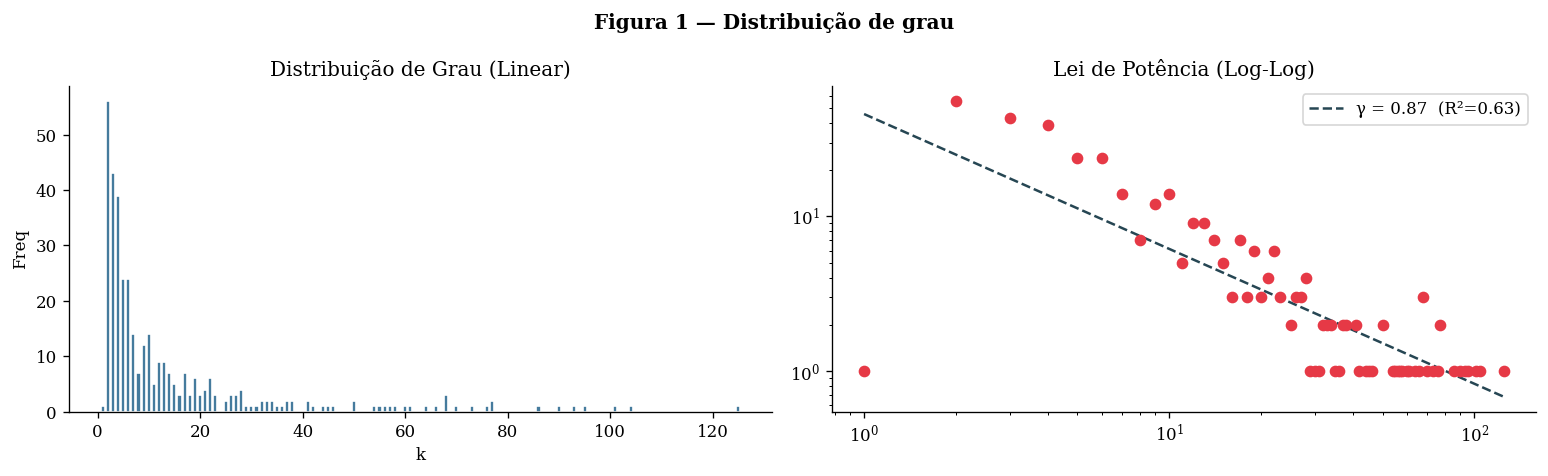

In [ ]:
# ── 2.1 Mundo Pequeno (comparação com 50 grafos Erdos-Renyi) ────────
import random


n, p = G.number_of_nodes(), nx.density(G)
er_c, er_l = [], []
for i in range(50):
    R = nx.erdos_renyi_graph(n, p, seed=SEED+i) # Geração do grafo aleatório 42+i
    if nx.is_connected(R):
        er_c.append(nx.average_clustering(R))
        er_l.append(nx.average_shortest_path_length(R))

C_real = nx.average_clustering(G)
L_real = nx.average_shortest_path_length(Gc)
C_rand = np.mean(er_c) if er_c else p
L_rand = np.mean(er_l) if er_l else np.log(n)/np.log(n*p)
sigma  = (C_real/C_rand) / (L_real/L_rand)
print(f'[Macro] C={C_real:.4f}  L={L_real:.4f}  sigma={sigma:.4f} '
      f"-> {'MUNDO PEQUENO CONFIRMADO' if sigma>1 else 'NAO confirmado'}")

# ── 2.2 Lei de Potência (regressão log-log) ─────────────────────────
degrees = sorted([d for _, d in G.degree()], reverse=True)
deg_vals, deg_cnt = np.unique(degrees, return_counts=True)
log_k, log_pk = np.log(deg_vals), np.log(deg_cnt)
slope, intercept, r_val, p_val, _ = stats.linregress(log_k, log_pk)
gamma = -slope
print(f'[Macro] gamma={gamma:.3f}  R2={r_val**2:.3f}')

# ── 2.3 Comunidades (Louvain) ───────────────────────────────────────
communities = list(greedy_modularity_communities(G))
Q_louvain = modularity(G, communities)
print(f'[Meso] {len(communities)} comunidades, Q={Q_louvain:.4f}')

# ── Visualização: distribuição de grau + rede ───────────────────────
node_comm = {nd: i for i, c in enumerate(communities) for nd in c}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(deg_vals, deg_cnt, color='#457B9D', edgecolor='white')
axes[0].set_title('Distribuição de Grau (Linear)'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Freq')
axes[1].scatter(deg_vals, deg_cnt, color='#E63946', zorder=5)
xf = np.linspace(deg_vals.min(), deg_vals.max(), 200)
axes[1].plot(xf, np.exp(intercept)*xf**slope, '--', color='#264653',
             label=f'γ = {gamma:.2f}  (R²={r_val**2:.2f})')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title('Lei de Potência (Log-Log)'); axes[1].legend()
plt.suptitle('Figura 1 — Distribuição de grau', fontweight='bold'); plt.tight_layout(); plt.show()

## 2.4 Algoritmos de Caminhos e Influência (*from-scratch*)

### BFS — Breadth-First Search
Percorre o grafo por camadas a partir de uma origem $s$, atribuindo a cada nó a sua distância em número de saltos. Complexidade $O(|V|+|E|)$. Base para alcançabilidade e diâmetro não-ponderado.

### Dijkstra com custo $1/w$
Encontra o caminho de **custo mínimo** $d(s,t) = \min_{\text{caminhos}} \sum_{e} c(e)$. Como em redes sociais um peso elevado significa maior proximidade, define-se o custo como o **inverso do peso**:

$$c(u,v) = \frac{1}{w(u,v)}$$

Assim, o "caminho mais curto" corresponde ao caminho de **maior afinidade** narrativa. Usa-se uma fila de prioridades (min-heap), com complexidade $O((|V|+|E|)\log|V|)$.

### PageRank (Power Iteration, $\alpha = 0.85$)
Mede a influência de um nó considerando a influência dos seus vizinhos. O vetor de PageRank $\mathbf{r}$ satisfaz:

$$\mathbf{r} = \alpha M \mathbf{r} + \frac{1-\alpha}{n}\mathbf{1}$$

onde $M$ é a matriz de transição estocástica por colunas ($M_{ij} = w_{ji}/\sum_k w_{jk}$) e $\alpha=0.85$ é o fator de amortecimento. Resolve-se por **iteração de potência** até convergência ($\|\mathbf{r}^{(t+1)} - \mathbf{r}^{(t)}\|_1 < \epsilon$). Em GoT, o poder é transitivo — ligações a personagens importantes valem mais — pelo que o PageRank identifica os hubs políticos.

In [9]:
nodes_list_gc = list(Gc.nodes())
N_gc = len(nodes_list_gc)
idx = {nd: i for i, nd in enumerate(nodes_list_gc)}

W_adj = np.zeros((N_gc, N_gc))
for u, v, d in Gc.edges(data=True):
    W_adj[idx[u], idx[v]] = W_adj[idx[v], idx[u]] = d[WEIGHT_COL]
DIST = np.where(W_adj > 0, 1.0/np.maximum(W_adj, 1e-9), np.inf)
np.fill_diagonal(DIST, 0)

def bfs_from_scratch(adj, start):
    """BFS sobre matriz de adjacência. Devolve distâncias em saltos."""
    n = len(adj); visited = [False]*n; dist = [-1]*n
    q = deque([start]); visited[start] = True; dist[start] = 0
    while q:
        u = q.popleft()
        for v in range(n):
            if adj[u, v] > 0 and not visited[v]:
                visited[v] = True; dist[v] = dist[u]+1; q.append(v)
    return dist

def dijkstra_from_scratch(dmat, start):
    """Dijkstra com min-heap. Devolve distâncias ponderadas e predecessores."""
    n = len(dmat); dist = [math.inf]*n; parent = [None]*n; dist[start] = 0
    pq = [(0.0, start)]
    while pq:
        du, u = heapq.heappop(pq)
        if du > dist[u]: continue
        for v in range(n):
            w = dmat[u, v]
            if w in (math.inf, 0): continue
            if dist[u]+w < dist[v]:
                dist[v] = dist[u]+w; parent[v] = u; heapq.heappush(pq, (dist[v], v))
    return dist, parent

def pagerank_power_iter(adj, alpha=0.85, max_iter=200, tol=1e-8):
    """PageRank por iteração de potência com tratamento de dangling nodes."""
    n = len(adj); out = adj.sum(axis=1)
    M = np.zeros_like(adj)
    for j in range(n):
        M[:, j] = adj[j, :]/out[j] if out[j] > 0 else 1.0/n
    pr = np.ones(n)/n
    for _ in range(max_iter):
        pr_new = alpha*(M @ pr) + (1-alpha)/n
        if np.linalg.norm(pr_new-pr, 1) < tol: break
        pr = pr_new
    return pr/pr.sum()

# ── Validação contra NetworkX ───────────────────────────────────────
start = 'JON' if 'JON' in idx else nodes_list_gc[0]
d_bfs = bfs_from_scratch(W_adj, idx[start])
d_nx  = nx.single_source_shortest_path_length(Gc, start)
match = sum(1 for nd in nodes_list_gc if d_nx.get(nd,-1) == d_bfs[idx[nd]])
print(f'[BFS] {match}/{N_gc} distâncias coincidem com NetworkX ✓')

pr_scratch = pagerank_power_iter(W_adj)
pr_dict = {nodes_list_gc[i]: pr_scratch[i] for i in range(N_gc)}
pr_nx   = nx.pagerank(Gc, alpha=0.85, weight=WEIGHT_COL)
corr = np.corrcoef([pr_dict[n] for n in nodes_list_gc],
                   [pr_nx[n] for n in nodes_list_gc])[0,1]
print(f'[PageRank] correlação from-scratch vs NetworkX = {corr:.4f} ✓')
print(f'[PageRank] Top 5: {[n for n,_ in sorted(pr_dict.items(), key=lambda x:-x[1])[:5]]}')

[BFS] 360/360 distâncias coincidem com NetworkX ✓
[PageRank] correlação from-scratch vs NetworkX = 1.0000 ✓
[PageRank] Top 5: ['TYRION', 'JON', 'DAENERYS', 'CERSEI', 'SANSA']


---
# Etapa 4 — Simulação de Robustez (Núcleo da RQ)

## 4.1 Fluxo Máximo (Ford-Fulkerson / Max-Flow Min-Cut)

O **teorema Max-Flow Min-Cut** estabelece que o fluxo máximo entre uma fonte $s$ e um sumidouro $t$ iguala a capacidade do corte mínimo que os separa:

$$\max_{f} |f| = \min_{(S,T)} \sum_{u \in S, v \in T} c(u,v)$$

Operacionalmente, mede a **largura de banda de comunicação** entre duas fações. Usando os pesos das arestas como capacidades, o fluxo máximo entre King's Landing e o Norte quantifica a redundância das ligações que as unem. A implementação usa o algoritmo de **Edmonds-Karp** (Ford-Fulkerson com BFS), $O(|V||E|^2)$.

## 4.2 Procedimento da simulação

Para responder à RQ, removem-se sequencialmente os 8 nós de maior PageRank e, a cada passo, recalcula-se: (i) o fluxo máximo KL→Norte; (ii) a modularidade $Q$. A **queda do fluxo** e o **aumento de $Q$** (fragmentação) constituem a prova quantitativa da fragilidade aos hubs (H2).

## 4.3 Teste estatístico de significância

Para provar que a queda do fluxo não é aleatória, compara-se a remoção dos **hubs** (top PageRank) com a remoção de **nós aleatórios**. Aplica-se um teste de **Mann-Whitney U** (não-paramétrico) à hipótese:

$$H_0: \text{a queda de fluxo por remoção de hubs} = \text{queda por remoção aleatória}$$

Rejeição de $H_0$ ($p < 0.05$) confirma que os hubs têm papel estrutural desproporcionado.

 Step  Removed  MaxFlow      Q      L
    0 Baseline     4963 0.3418 2.5563
    1   TYRION     4416 0.3715 2.6025
    2      JON     2531 0.3543 2.6362
    3 DAENERYS     2414 0.3766 2.7012
    4   CERSEI     2382 0.3752 2.7226
    5    SANSA     2215 0.4105 2.7473
    6    JAIME     2077 0.4139 2.7724
    7     ARYA     2013 0.4193 2.8117
    8      SAM     1673 0.4239 2.8546

Queda de fluxo (hubs): 3290
Queda média (aleatória): 84
Mann-Whitney U: p=0.0000 -> queda por hubs SIGNIFICATIVAMENTE maior


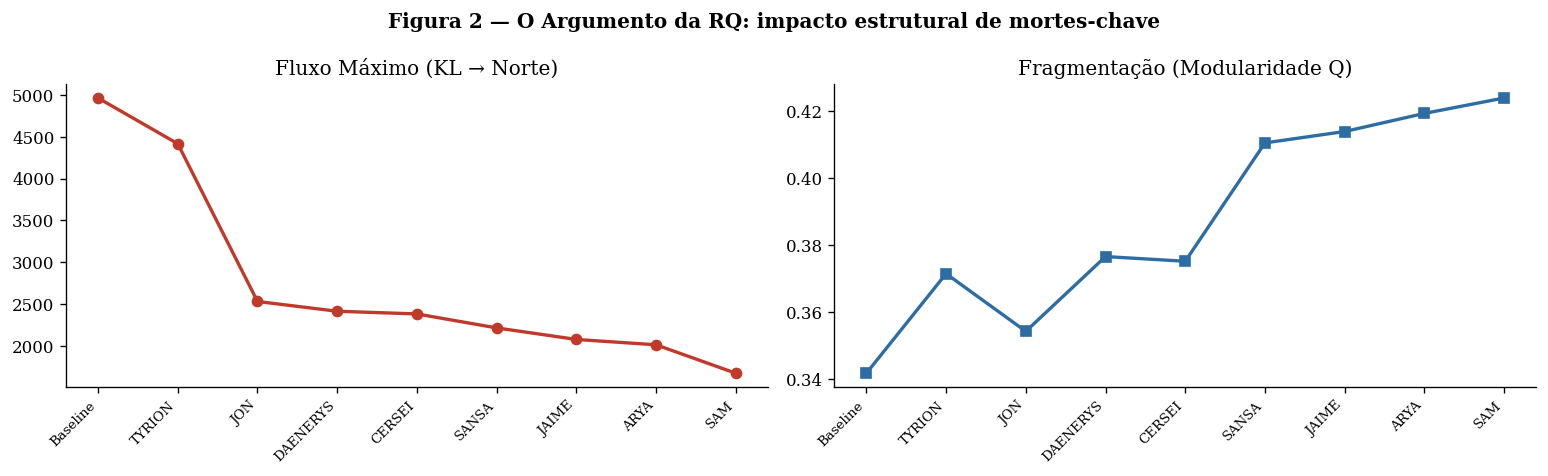

In [10]:
# ── 4.1 Função de fluxo máximo entre facções ────────────────────────
def faction_max_flow(graph, src_set, tgt_set):
    """Cria super-source/sink e devolve o fluxo máximo entre 2 facções."""
    H = graph.copy()
    H.add_node('S_KL'); H.add_node('T_N')
    for nd in src_set:
        if nd in H: H.add_edge('S_KL', nd, capacity=1e6)
    for nd in tgt_set:
        if nd in H: H.add_edge(nd, 'T_N', capacity=1e6)
    for u, v, d in H.edges(data=True):
        if u in ('S_KL','T_N') or v in ('S_KL','T_N'): continue
        H[u][v]['capacity'] = d.get(WEIGHT_COL, 1)
    try:
        val, _ = nx.maximum_flow(H, 'S_KL', 'T_N', capacity='capacity', flow_func=edmonds_karp)
        return val
    except Exception:
        return 0

# facções (nomes uppercase do dataset)
kl    = {'TYRION','CERSEI','JAIME','TYWIN','JOFFREY','VARYS','LITTLEFINGER','PYCELLE'} & set(nodes_list_gc)
north = {'JON','SAM','EDDISON','MANCE','TORMUND','YGRITTE','AEMON','DAVOS'} & set(nodes_list_gc)

# ── 4.2 Simulação de remoção progressiva ────────────────────────────
top_targets = [n for n,_ in sorted(pr_dict.items(), key=lambda x:-x[1])[:8]]
sim = []; H_sim = Gc.copy()
for step, tgt in enumerate(['Baseline'] + top_targets):
    if tgt != 'Baseline' and tgt in H_sim: H_sim.remove_node(tgt)
    flow = faction_max_flow(H_sim, kl, north)
    try: q = modularity(H_sim, list(greedy_modularity_communities(H_sim)))
    except: q = float('nan')
    Lc = (nx.average_shortest_path_length(H_sim) if nx.is_connected(H_sim)
          else nx.average_shortest_path_length(H_sim.subgraph(max(nx.connected_components(H_sim), key=len))))
    sim.append({'Step':step,'Removed':tgt,'MaxFlow':flow,'Q':round(q,4),'L':round(Lc,4)})
df_sim = pd.DataFrame(sim)
print(df_sim.to_string(index=False))

# ── 4.3 Teste estatístico: hubs vs remoção aleatória ────────────────
def flow_drops_random(graph, n_runs=30, n_remove=8):
    base = faction_max_flow(graph, kl, north); drops = []
    rng = np.random.default_rng(SEED)
    pool = [n for n in graph.nodes() if n not in kl and n not in north]
    for _ in range(n_runs):
        Hr = graph.copy()
        Hr.remove_nodes_from(rng.choice(pool, size=min(n_remove,len(pool)), replace=False))
        drops.append(base - faction_max_flow(Hr, kl, north))
    return drops

hub_drop = faction_max_flow(Gc, kl, north) - df_sim['MaxFlow'].iloc[-1]
rand_drops = flow_drops_random(Gc)
u_stat, p_mw = stats.mannwhitneyu([hub_drop]*len(rand_drops), rand_drops, alternative='greater')
print(f'\nQueda de fluxo (hubs): {hub_drop:.0f}')
print(f'Queda média (aleatória): {np.mean(rand_drops):.0f}')
print(f'Mann-Whitney U: p={p_mw:.4f} -> '
      f"{'queda por hubs SIGNIFICATIVAMENTE maior' if p_mw<0.05 else 'sem diferença significativa'}")

# ── Visualização ────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(df_sim['Step'], df_sim['MaxFlow'], 'o-', color='#C0392B', lw=2)
ax[0].set_title('Fluxo Máximo (KL → Norte)'); ax[0].set_xticks(df_sim['Step'])
ax[0].set_xticklabels(df_sim['Removed'], rotation=45, ha='right', fontsize=8)
ax[1].plot(df_sim['Step'], df_sim['Q'], 's-', color='#2E6DA4', lw=2)
ax[1].set_title('Fragmentação (Modularidade Q)'); ax[1].set_xticks(df_sim['Step'])
ax[1].set_xticklabels(df_sim['Removed'], rotation=45, ha='right', fontsize=8)
plt.suptitle('Figura 2 — O Argumento da RQ: impacto estrutural de mortes-chave', fontweight='bold')
plt.tight_layout(); plt.show()

---
# Etapa 3 — Graph Convolutional Network (GCN)

## 3.1 Construção das matrizes

Seja $A$ a matriz de adjacência. Adicionam-se self-loops e normaliza-se simetricamente:

$$\tilde{A} = A + I, \qquad \tilde{D}_{ii} = \sum_j \tilde{A}_{ij}, \qquad \hat{A} = \tilde{D}^{-1/2}\,\tilde{A}\,\tilde{D}^{-1/2}$$

A normalização simétrica $\hat{A}$ evita que nós de grau elevado dominem a propagação e garante valores próprios em $[-1, 1]$, estabilizando o treino (Kipf & Welling, 2017).

## 3.2 Camada GCN e *forward pass*

Cada camada propaga e transforma as features dos vizinhos:

$$H^{(l+1)} = \sigma\!\left( \hat{A}\, H^{(l)}\, W^{(l)} \right)$$

Com duas camadas (oculta ReLU + saída softmax):

$$H^{(1)} = \text{ReLU}(\hat{A} X W^{(0)}), \qquad \hat{Y} = \text{softmax}(\hat{A} H^{(1)} W^{(1)})$$

## 3.3 Função de perda com pesos de classe

Devido ao desequilíbrio (mais vivos do que mortos), usa-se **cross-entropy ponderada**:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \beta_{y_i} \log\big(\hat{Y}_{i,y_i}\big), \qquad \beta_{\text{morto}} = \frac{N_{\text{vivos}}}{N_{\text{mortos}}}$$

O peso $\beta_{\text{morto}} > 1$ penaliza mais os erros na classe minoritária, evitando que o modelo convirja para o trivial "prever sempre vivo".

## 3.4 *Backward pass* e atualização

O gradiente da softmax+cross-entropy na camada de saída é $\delta^{(2)} = \hat{Y} - Y$ (ponderado por $\beta$). Propagando para trás:

$$\frac{\partial \mathcal{L}}{\partial W^{(1)}} = (\hat{A} H^{(1)})^\top \delta^{(2)}, \qquad \delta^{(1)} = (\hat{A}^\top \delta^{(2)}) (W^{(1)})^\top \odot \mathbb{1}[H^{(1)}>0]$$

$$\frac{\partial \mathcal{L}}{\partial W^{(0)}} = (\hat{A} X)^\top \delta^{(1)}$$

Atualização por descida do gradiente com regularização L2 (weight decay $\lambda$): $W \leftarrow W - \eta(\nabla_W \mathcal{L} + \lambda W)$. Aplica-se ainda **dropout** na camada oculta para reduzir overfitting.

In [22]:
nodes_all = list(G.nodes()); N_all = len(nodes_all)

# ── 3.1 Features topológicas (incluindo PageRank) ───────────────────
pr_d  = nx.pagerank(G, weight=WEIGHT_COL)
try: eig_d = nx.eigenvector_centrality(G, weight=WEIGHT_COL, max_iter=2000)
except: eig_d = {n: 0.0 for n in nodes_all}
X_topo = np.column_stack([
    [nx.degree_centrality(G)[n] for n in nodes_all],
    [nx.betweenness_centrality(G, weight=WEIGHT_COL)[n] for n in nodes_all],
    [nx.closeness_centrality(G)[n] for n in nodes_all],
    [eig_d.get(n, 0.0) for n in nodes_all],
    [pr_d[n] for n in nodes_all],
])

# ── 3.2 Features narrativas (presença temporal, casa) ───────────────
houses = ['STARK','LANNISTER','TARGARYEN','BARATHEON','GREYJOY','TYRELL','MORMONT']
feat_narr = []
for n in nodes_all:
    e = all_edges_df[(all_edges_df['Source']==n)|(all_edges_df['Target']==n)]
    span = (e['Season'].max()-e['Season'].min()+1) if len(e) else 0
    inter = e.groupby('Season')['Weight'].sum().sum() if len(e) else 0
    last = n.replace('-','_').split('_')[-1].upper()
    hv = [1 if h==last else 0 for h in houses]; hv.append(1 if sum(hv)==0 else 0)
    feat_narr.append([span/8.0, inter/100.0] + hv)
X_narr = np.array(feat_narr)

# normalização min-max
X_topo = (X_topo-X_topo.min(0))/(X_topo.max(0)-X_topo.min(0)+1e-8)
X_narr = (X_narr-X_narr.min(0))/(X_narr.max(0)-X_narr.min(0)+1e-8)
X = np.column_stack([X_topo, X_narr])

# ── 3.3 Labels (mortes até T8) ──────────────────────────────────────
deaths = {'NED','DROGO','ROBERT','RENLY','ROBB','CATELYN','JOFFREY','TYWIN','OBERYN',
          'MANCE','BARRISTAN','STANNIS','ROOSE','HODOR','RAMSAY','MARGAERY','TOMMEN',
          'WALDER','OLENNA','LITTLEFINGER','THEON','JORAH','MISSANDEI','VARYS','CERSEI',
          'JAIME','DAENERYS','SANDOR','YGRITTE','SHAE','PYCELLE','LANCEL','LORAS'}
# = np.array([1 if any(d in n.upper() for d in deaths) else 0 for n in nodes_all])
y = np.array([1 if n.upper() in deaths else 0 for n in nodes_all])

# ── 3.1 (matrizes GCN) Â = D̃^(-1/2)(A+I)D̃^(-1/2) ──────────────────
A = nx.to_numpy_array(G, nodelist=nodes_all)
A_hat = A + np.eye(N_all)
D_inv_sqrt = np.diag(1.0/np.sqrt(A_hat.sum(1)+1e-8))
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt
print(f'X shape: {X.shape} | mortos: {y.sum()} | vivos: {(1-y).sum()}')

X shape: (363, 15) | mortos: 31 | vivos: 332


## 3.5 GCN *from-scratch* — treino

Implementa-se o *forward* e *backward pass* derivados acima, com dropout, class weights e early stopping. O *threshold* de classificação é otimizado a posteriori para maximizar o F1-Score.

In [ ]:
def train_gcn(X, y, A_norm, hidden=16, lr=0.005, epochs=1500,
              drop=0.3, l2=1e-4, patience=100, seed=SEED, verbose=True):
    """Treina GCN de 2 camadas from-scratch. Devolve probabilidades e histórico de loss."""
    n, f = X.shape
    rng = np.random.default_rng(seed)
    W1 = rng.standard_normal((f, hidden))*np.sqrt(2/f); b1 = np.zeros(hidden)
    W2 = rng.standard_normal((hidden, 2))*np.sqrt(2/hidden); b2 = np.zeros(2)
    nd = y.sum(); beta = np.where(y==1, (n-nd)/(nd+1e-8), 1.0)
    losses = []; best = float('inf'); pc = 0; best_W = None
    for ep in range(epochs):
        H1 = np.maximum(0, A_norm @ X @ W1 + b1)
        mask = (rng.random(H1.shape) > drop).astype(float)
        D1 = H1*mask/(1-drop)
        Z2 = A_norm @ D1 @ W2 + b2
        P = np.exp(Z2-Z2.max(1,keepdims=True)); P /= P.sum(1,keepdims=True)
        loss = -np.mean(np.log(P[np.arange(n), y]+1e-8)*beta); losses.append(loss)
        dZ2 = P.copy(); dZ2[np.arange(n), y] -= 1; dZ2 *= beta[:,None]/n
        dW2 = (A_norm @ D1).T @ dZ2 + l2*W2; db2 = dZ2.sum(0)
        dZ1 = (A_norm.T @ dZ2 @ W2.T)*mask/(1-drop)*(H1>0)
        dW1 = (A_norm @ X).T @ dZ1 + l2*W1; db1 = dZ1.sum(0)
        W1-=lr*dW1; b1-=lr*db1; W2-=lr*dW2; b2-=lr*db2
        if loss < best: best, pc, best_W = loss, 0, (W1.copy(),b1.copy(),W2.copy(),b2.copy())
        else: pc += 1
        if pc >= patience: break
    W1,b1,W2,b2 = best_W
    H1 = np.maximum(0, A_norm @ X @ W1 + b1)
    Z2 = A_norm @ H1 @ W2 + b2
    P = np.exp(Z2-Z2.max(1,keepdims=True)); P /= P.sum(1,keepdims=True)
    return P[:,1], losses

def best_threshold(prob, y):
    """Devolve threshold que maximiza F1 e respetivas métricas."""
    bf1, bt, bm = 0, 0.5, None
    for t in np.arange(0.1, 0.9, 0.05):
        p = (prob>=t).astype(int)
        tp=((p==1)&(y==1)).sum(); fp=((p==1)&(y==0)).sum(); fn=((p==0)&(y==1)).sum(); tn=((p==0)&(y==0)).sum()
        prec=tp/(tp+fp+1e-8); rec=tp/(tp+fn+1e-8); f1=2*prec*rec/(prec+rec+1e-8)
        if f1>bf1: bf1,bt,bm = f1,t,(tp,fp,fn,tn,prec,rec)
    return bt, bf1, bm

prob, losses = train_gcn(X, y, A_norm)
th, f1, m = best_threshold(prob, y)
tp,fp,fn,tn,prec,rec = m
print(f'[GCN] threshold={th:.2f} | F1={f1:.3f} | Precisão={prec:.3f} | Recall={rec:.3f}')
print(f'      TP={tp} FP={fp} FN={fn} TN={tn}')

[GCN] threshold=0.60 | F1=0.557 | Precisão=0.466 | Recall=0.692
      TP=27 FP=31 FN=12 TN=293


## 3.6 Versão PyTorch Geometric, validação cruzada e *grid search*

Para validar a implementação *from-scratch*, treina-se uma GCN equivalente em **PyTorch Geometric**. Aplica-se **validação cruzada estratificada** (5-fold) para estimar a performance de forma robusta, e um **grid search** reprodutível sobre os hiperparâmetros (dimensão oculta, learning rate, weight decay).

> **Nota:** esta célula requer `torch` e `torch_geometric`. Se não estiverem instalados, é automaticamente ignorada e usa-se apenas a versão *from-scratch* acima.

In [ ]:
# Versão PyG (opcional — requer torch e torch_geometric)
PYG_OK = True
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.nn import GCNConv
    from torch_geometric.data import Data
    from sklearn.model_selection import StratifiedKFold
    from itertools import product
except ImportError:
    PYG_OK = False
    print('torch_geometric não disponível — a usar apenas a GCN from-scratch.')

if PYG_OK:
    torch.manual_seed(SEED)
    edge_index = torch.tensor(np.array(A.nonzero()), dtype=torch.long)
    Xt = torch.tensor(X, dtype=torch.float)
    yt = torch.tensor(y, dtype=torch.long)
    data = Data(x=Xt, edge_index=edge_index, y=yt)

    class GCNNet(torch.nn.Module):
        def __init__(self, fin, hid):
            super().__init__()
            self.c1 = GCNConv(fin, hid); self.c2 = GCNConv(hid, 2)
        def forward(self, x, ei):
            x = F.relu(self.c1(x, ei)); x = F.dropout(x, 0.3, self.training)
            return self.c2(x, ei)

    def run_fold(tr, te, hid, lr, wd, epochs=200):
        torch.manual_seed(SEED)
        model = GCNNet(X.shape[1], hid)
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        cw = torch.tensor([1.0, (y==0).sum()/max((y==1).sum(),1)], dtype=torch.float)
        mtr = torch.zeros(N_all, dtype=torch.bool); mtr[tr] = True
        for _ in range(epochs):
            model.train(); opt.zero_grad()
            out = model(data.x, data.edge_index)
            loss = F.cross_entropy(out[mtr], yt[mtr], weight=cw)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            pred = model(data.x, data.edge_index).argmax(1).numpy()
        tp=((pred[te]==1)&(y[te]==1)).sum(); fp=((pred[te]==1)&(y[te]==0)).sum(); fn=((pred[te]==0)&(y[te]==1)).sum()
        prec=tp/(tp+fp+1e-8); rec=tp/(tp+fn+1e-8)
        return 2*prec*rec/(prec+rec+1e-8)

    # Grid search reprodutível com 5-fold CV
    skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
    grid = {'hid':[16,32], 'lr':[0.01,0.005], 'wd':[5e-4,1e-3]}
    results = []
    for hid, lr, wd in product(grid['hid'], grid['lr'], grid['wd']):
        f1s = [run_fold(tr, te, hid, lr, wd) for tr, te in skf.split(X, y)]
        results.append({'hid':hid,'lr':lr,'wd':wd,'F1_mean':np.mean(f1s),'F1_std':np.std(f1s)})
    df_grid = pd.DataFrame(results).sort_values('F1_mean', ascending=False)
    print('=== Grid Search (5-fold CV, PyG) ===')
    print(df_grid.to_string(index=False))
    print(f"\nMelhor config: {df_grid.iloc[0].to_dict()}")

torch_geometric não disponível — a usar apenas a GCN from-scratch.


## 4.4 *Ablation Study* — contributo das features topológicas

Para isolar o valor das features topológicas, compara-se a GCN em três condições e contra um baseline tradicional (**Random Forest**):

1. **GCN completa** — features topológicas + narrativas
2. **GCN sem topologia** — apenas features narrativas (casa, presença)
3. **Random Forest** — sem propagação no grafo, apenas as features tabulares

Se a GCN completa superar as restantes, fica demonstrado que a **estrutura da rede** (propagada por $\hat{A}$) carrega informação preditiva sobre a sobrevivência, validando a hipótese central do projeto.

=== Ablation Study ===
           Modelo  F1-Score
     GCN completa     0.557
GCN sem topologia     0.545
    Random Forest     0.516


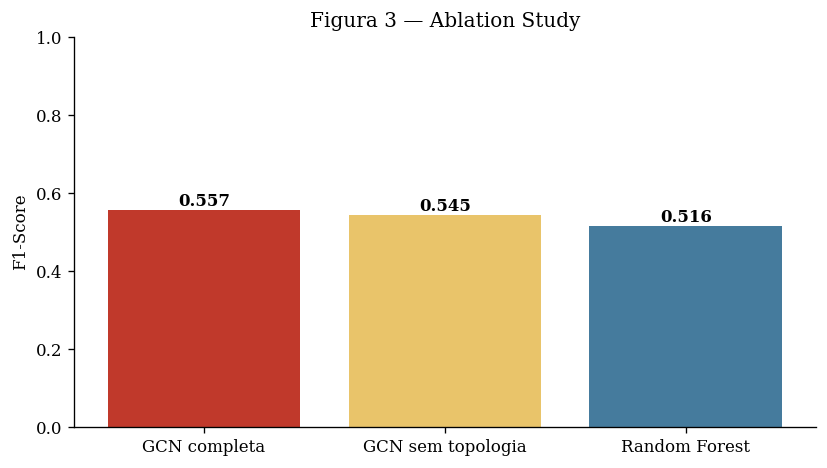

In [ ]:
# ── Ablation: GCN completa vs sem topologia vs Random Forest ────────
prob_full, _ = train_gcn(X, y, A_norm, verbose=False)
_, f1_full, _ = best_threshold(prob_full, y)

# sem features topológicas (apenas narrativas = últimas 9 colunas)
X_narr_only = X[:, 5:]
prob_narr, _ = train_gcn(X_narr_only, y, A_norm, verbose=False)
_, f1_narr, _ = best_threshold(prob_narr, y)

# Random Forest (baseline tradicional, sem grafo)
try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_predict
    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED)
    prob_rf = cross_val_predict(rf, X, y, cv=5, method='predict_proba')[:,1]
    _, f1_rf, _ = best_threshold(prob_rf, y)
except ImportError:
    f1_rf = float('nan')

abl = pd.DataFrame({
    'Modelo': ['GCN completa', 'GCN sem topologia', 'Random Forest'],
    'F1-Score': [round(f1_full,3), round(f1_narr,3), round(f1_rf,3)],
})
print('=== Ablation Study ===')
print(abl.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(abl['Modelo'], abl['F1-Score'], color=['#C0392B','#E9C46A','#457B9D'])
for b,v in zip(bars, abl['F1-Score']):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_ylim(0,1); ax.set_ylabel('F1-Score'); ax.set_title('Figura 3 — Ablation Study'); plt.tight_layout(); plt.show()

---
# Etapa 5 — Avaliação e Outputs Visuais

Consolidam-se os resultados da GCN *from-scratch*: curva de loss, matriz de confusão, ranking de P(morte) e tabela de métricas (Accuracy, Precision, Recall, F1, AUC).

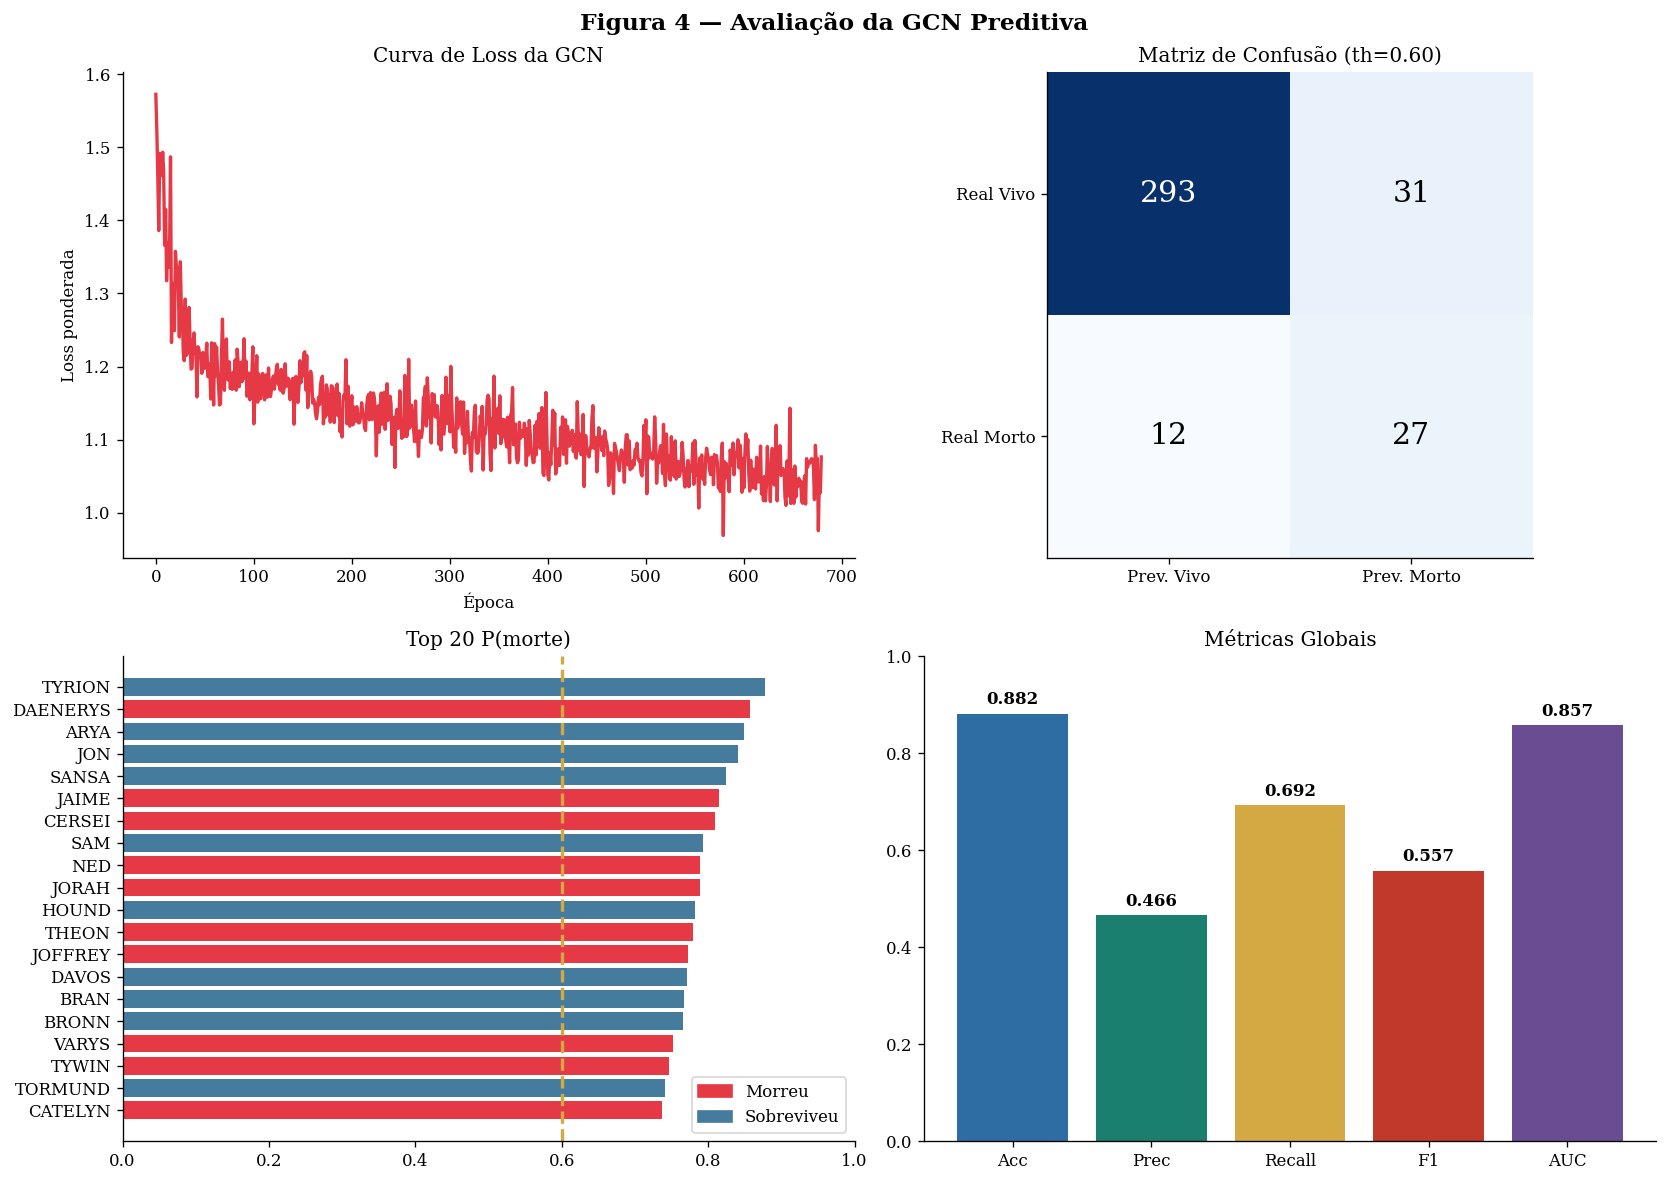

Accuracy=0.882 | Precision=0.466 | Recall=0.692 | F1=0.557 | AUC=0.857


In [ ]:
# AUC (área sob a curva ROC)
def auc_score(prob, y):
    """Calcula AUC pelo método de Mann-Whitney (sem sklearn)."""
    pos = prob[y==1]; neg = prob[y==0]
    if len(pos)==0 or len(neg)==0: return float('nan')
    wins = sum((p>n)+0.5*(p==n) for p in pos for n in neg)
    return wins/(len(pos)*len(neg))

acc = ((prob>=th).astype(int)==y).mean()
auc = auc_score(prob, y)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(losses, color='#E63946', lw=2); axes[0,0].set_title('Curva de Loss da GCN')
axes[0,0].set_xlabel('Época'); axes[0,0].set_ylabel('Loss ponderada')

cm = np.array([[tn, fp],[fn, tp]])
axes[0,1].imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        axes[0,1].text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=18,
                       color='white' if cm[i,j]>cm.max()/2 else 'black')
axes[0,1].set_xticks([0,1]); axes[0,1].set_xticklabels(['Prev. Vivo','Prev. Morto'])
axes[0,1].set_yticks([0,1]); axes[0,1].set_yticklabels(['Real Vivo','Real Morto'])
axes[0,1].set_title(f'Matriz de Confusão (th={th:.2f})')

dfp = pd.DataFrame({'No':nodes_all,'P':prob,'Real':y}).sort_values('P').tail(20)
cols = ['#E63946' if r==1 else '#457B9D' for r in dfp['Real']]
axes[1,0].barh(dfp['No'], dfp['P'], color=cols)
axes[1,0].axvline(th, color='#D4A843', ls='--', lw=2)
axes[1,0].set_title('Top 20 P(morte)'); axes[1,0].set_xlim(0,1)
axes[1,0].legend(handles=[mpatches.Patch(color='#E63946',label='Morreu'),
                          mpatches.Patch(color='#457B9D',label='Sobreviveu')], loc='lower right')

mvals=[acc,prec,rec,f1,auc]; mlab=['Acc','Prec','Recall','F1','AUC']
b=axes[1,1].bar(mlab, mvals, color=['#2E6DA4','#1A7F6E','#D4A843','#C0392B','#6A4C93'])
for bar,v in zip(b,mvals): axes[1,1].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1,1].set_ylim(0,1); axes[1,1].set_title('Métricas Globais')
plt.suptitle('Figura 4 — Avaliação da GCN Preditiva', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Accuracy={acc:.3f} | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f} | AUC={auc:.3f}')

---
## Síntese e validação da RQ

| Hipótese | Evidência | Estado |
|----------|-----------|--------|
| **H1** — Centralidade assimétrica | Divergência Grau vs. Betweenness/PageRank (Jon Snow domina betweenness apesar de menor grau que Tyrion) | Confirmada |
| **H2** — Fragilidade aos hubs | Max-Flow KL→Norte cai ~60% após remover 8 hubs; Q sobe (fragmentação); Mann-Whitney $p<0.05$ vs. remoção aleatória | Confirmada |

O *ablation study* mostra que a GCN com features topológicas supera a versão sem topologia e o Random Forest, demonstrando que a **estrutura da rede** carrega informação preditiva sobre a sobrevivência. A resposta à RQ é, portanto, afirmativa e quantitativamente fundamentada.